In [1]:
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch

from inference.generate import generate
from models.qwen3 import Qwen3

/Users/hyerra/Documents/weft/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_ID = "Qwen/Qwen3-0.6B"
DTYPE = torch.bfloat16
BATCH_SIZE = 2
PROMPT_TOKENS = [128, 512, 1024]
NEW_TOKENS = 32
WARMUP_TOKENS = 4
REPEATS = 5
PERCENTILES = [50, 90, 95, 99]
SEED = 0

In [3]:
def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def sync(device):
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def reset_memory(device):
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()


def peak_memory(device):
    if device.type == "cuda":
        return torch.cuda.max_memory_allocated()
    if device.type == "mps":
        return torch.mps.current_allocated_memory()
    return 0

In [4]:
@dataclass
class Run:
    batch_size: int
    prompt_tokens: int
    ttft_s: float
    itl_s: list[float]
    peak_mem: int = 0

    @property
    def ttft_ms(self):
        return 1e3 * self.ttft_s

    @property
    def itl_ms(self):
        return 1e3 * np.array(self.itl_s)

    @property
    def tpot_ms(self):
        return float(np.mean(self.itl_ms))

    @property
    def input_tps(self):
        return self.batch_size * self.prompt_tokens / self.ttft_s

    @property
    def output_tps(self):
        return self.batch_size * 1e3 / self.tpot_ms

    def itl_ms_at(self, percentile):
        return float(np.percentile(self.itl_ms, percentile))

    def output_tps_at(self, percentile):
        return self.batch_size * 1e3 / self.itl_ms_at(percentile)


@dataclass
class Sweep:
    name: str
    device: str
    dtype: str
    batch_size: int
    runs: list[Run]

In [5]:
def measure(model, input_ids, attn_mask, new_tokens, device, stream=generate):
    ttft_s, itl_s = 0.0, []

    sync(device)
    t_prev = time.perf_counter()

    for step, _ in enumerate(stream(model, input_ids, attn_mask, new_tokens)):
        sync(device)
        t_now = time.perf_counter()
        dt, t_prev = t_now - t_prev, t_now

        if step == 0:
            ttft_s = dt
        else:
            itl_s.append(dt)

    return ttft_s, itl_s

In [6]:
device = pick_device()
model = Qwen3.from_pretrained(MODEL_ID, dtype=DTYPE).to(device)
device

Loading weights: 100%|██████████| 311/311 [00:00<00:00, 5764.59it/s]


device(type='mps')

In [7]:
def synthetic_prompt(batch_size, prompt_tokens, vocab_size, device):
    g = torch.Generator().manual_seed(SEED)
    input_ids = torch.randint(0, vocab_size, (batch_size, prompt_tokens), generator=g)
    return input_ids.to(device), torch.ones_like(input_ids).to(device)


def run_sweep(model, name, device, stream=generate):
    vocab_size = model.lm_head.out_features
    runs = []

    for prompt_tokens in PROMPT_TOKENS:
        input_ids, attn_mask = synthetic_prompt(BATCH_SIZE, prompt_tokens, vocab_size, device)

        measure(model, input_ids, attn_mask, WARMUP_TOKENS, device, stream)

        reset_memory(device)
        ttft_s, itl_s = [], []
        for _ in range(REPEATS):
            t, itl = measure(model, input_ids, attn_mask, NEW_TOKENS, device, stream)
            ttft_s.append(t)
            itl_s.extend(itl)

        run = Run(
            batch_size=BATCH_SIZE,
            prompt_tokens=prompt_tokens,
            ttft_s=float(np.mean(ttft_s)),
            itl_s=itl_s,
            peak_mem=peak_memory(device),
        )
        runs.append(run)
        print(f"prompt={prompt_tokens:5d}  ttft {run.ttft_ms:8.1f} ms  in {run.input_tps:8.1f} tok/s  out {run.output_tps:6.2f} tok/s")

    return Sweep(name=name, device=str(device), dtype=str(DTYPE), batch_size=BATCH_SIZE, runs=runs)


def summary(sweep):
    print(f"{sweep.name}  {sweep.device}  {sweep.dtype}  batch={sweep.batch_size}")
    print("  prompt  " + "".join(f"{f'p{p}':>20}" for p in PERCENTILES))
    for run in sweep.runs:
        cells = "".join(f"{run.itl_ms_at(p):9.1f}ms{run.output_tps_at(p):7.1f}/s" for p in PERCENTILES)
        print(f"  {run.prompt_tokens:6d}  {cells}")

In [8]:
sweep = run_sweep(model, "baseline", device)

prompt=  128  ttft    171.6 ms  in   1491.9 tok/s  out  10.05 tok/s
prompt=  512  ttft   3719.3 ms  in    275.3 tok/s  out   0.99 tok/s
prompt= 1024  ttft   3613.7 ms  in    566.7 tok/s  out   0.50 tok/s


In [9]:
summary(sweep)

baseline  mps  torch.bfloat16  batch=2
  prompt                   p50                 p90                 p95                 p99
     128      195.3ms   10.2/s    205.8ms    9.7/s    216.7ms    9.2/s    296.6ms    6.7/s
     512      916.5ms    2.2/s   5482.3ms    0.4/s   6263.2ms    0.3/s   8847.5ms    0.2/s
    1024     1749.6ms    1.1/s   7390.9ms    0.3/s   8345.9ms    0.2/s  11063.8ms    0.2/s


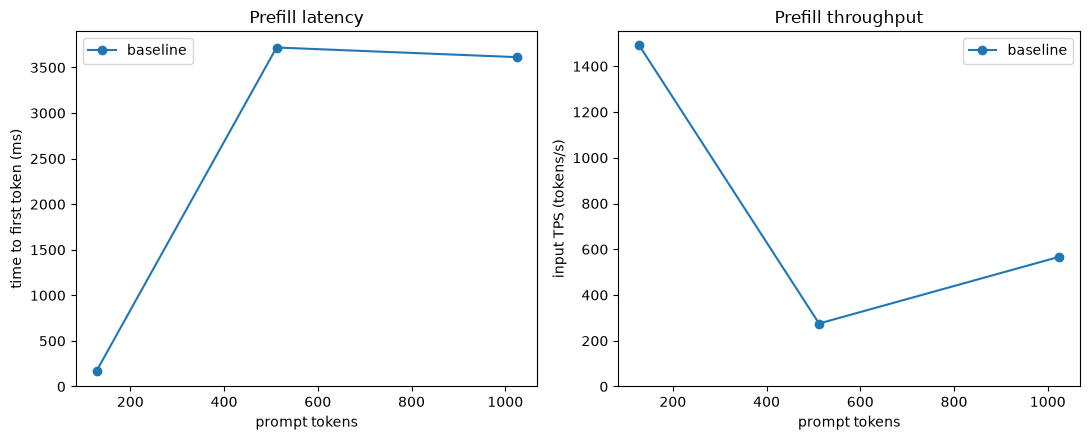

In [10]:
x = [r.prompt_tokens for r in sweep.runs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.plot(x, [r.ttft_ms for r in sweep.runs], marker="o", label=sweep.name)
ax1.set_xlabel("prompt tokens")
ax1.set_ylabel("time to first token (ms)")
ax1.set_title("Prefill latency")
ax1.set_ylim(0, None)
ax1.legend()

ax2.plot(x, [r.input_tps for r in sweep.runs], marker="o", label=sweep.name)
ax2.set_xlabel("prompt tokens")
ax2.set_ylabel("input TPS (tokens/s)")
ax2.set_title("Prefill throughput")
ax2.set_ylim(0, None)
ax2.legend()

fig.tight_layout()
plt.show()

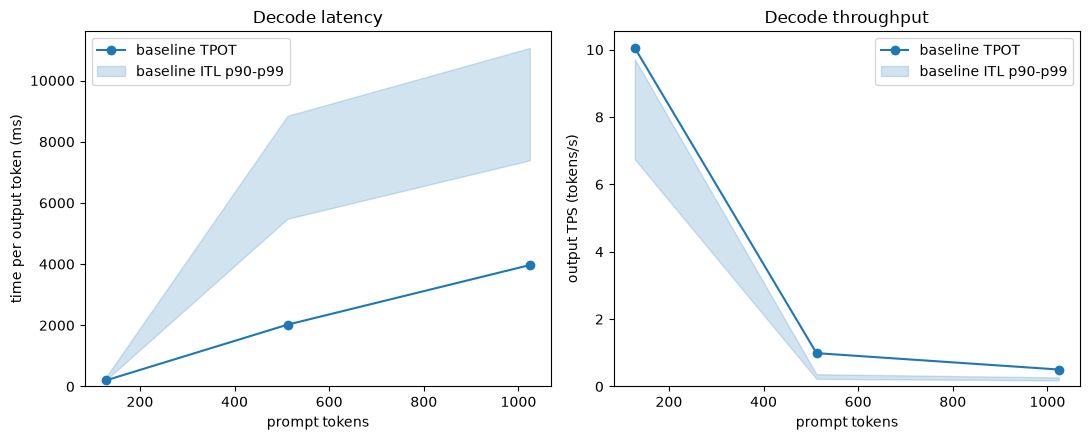

In [11]:
x = [r.prompt_tokens for r in sweep.runs]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

line, = ax1.plot(x, [r.tpot_ms for r in sweep.runs], marker="o", label=f"{sweep.name} TPOT")
ax1.fill_between(x, [r.itl_ms_at(90) for r in sweep.runs], [r.itl_ms_at(99) for r in sweep.runs],
                 alpha=0.2, color=line.get_color(), label=f"{sweep.name} ITL p90-p99")
ax1.set_xlabel("prompt tokens")
ax1.set_ylabel("time per output token (ms)")
ax1.set_title("Decode latency")
ax1.set_ylim(0, None)
ax1.legend()

line, = ax2.plot(x, [r.output_tps for r in sweep.runs], marker="o", label=f"{sweep.name} TPOT")
ax2.fill_between(x, [r.output_tps_at(99) for r in sweep.runs], [r.output_tps_at(90) for r in sweep.runs],
                 alpha=0.2, color=line.get_color(), label=f"{sweep.name} ITL p90-p99")
ax2.set_xlabel("prompt tokens")
ax2.set_ylabel("output TPS (tokens/s)")
ax2.set_title("Decode throughput")
ax2.set_ylim(0, None)
ax2.legend()

fig.tight_layout()
plt.show()